In [1]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from scdeepsim.plot import compare_umap
from scdeepsim.quality import knn_discriminability, rf_discriminability
import scvi

In [2]:
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)

muris_10k =  muris[np.random.choice(muris.n_obs, 10000, replace=False)]
sc.pp.highly_variable_genes(muris_10k, flavor='seurat_v3', n_top_genes=2000)
muris_10k = muris_10k[:, muris_10k.var['highly_variable']]
muris_10k = muris_10k.copy()
muris_10k.X = muris_10k.X.toarray() # convert to dense matrix 
muris_10k.X
muris_10k.obs

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: Trying to modify attribute `._uns` of view, initializing view as actual.


,celltype,n_genes,counts
TTTACTGCACCATGTA-1,Lung,254,370.0
CCGTGGATCCTGCCAT-1,Kidney,3481,11520.0
CCTACCACATTGGCGC-1,Thymus,2717,8576.0
GGCGTGTAGGCGCTCT-1,Lung,236,347.0
AGATCTGTCTCACATT-1,Lung,1338,3184.0
...,...,...,...
TTGCCGTAGGGCTTCC-1,Spleen,1571,6209.0
AACCATGTCAGTACGT-1,Tongue,2017,10635.0
69600,Trachea,816,1305.0
444986,Trachea,2301,9015.0


In [ ]:
# from scdesigner.simulators import NegBinCopula

# nbc = NegBinCopula(mean_formula = "~ celltype")
# nbc.fit(muris_10k, max_epochs=300, top_k=100)
# nbc_samples = nbc.sample(obs=muris_10k.obs)

Estimating top-k copula covariance: 100%|██████████| 10/10 [00:02<00:00,  4.26it/s]


In [3]:
muris_10k.layers

Layers with keys: 

In [4]:
processed_muris_10k = muris_10k.copy()
sc.pp.normalize_total(processed_muris_10k)
sc.pp.log1p(processed_muris_10k)

In [5]:
muris_10k.obs

,celltype,n_genes,counts
TTTACTGCACCATGTA-1,Lung,254,370.0
CCGTGGATCCTGCCAT-1,Kidney,3481,11520.0
CCTACCACATTGGCGC-1,Thymus,2717,8576.0
GGCGTGTAGGCGCTCT-1,Lung,236,347.0
AGATCTGTCTCACATT-1,Lung,1338,3184.0
...,...,...,...
TTGCCGTAGGGCTTCC-1,Spleen,1571,6209.0
AACCATGTCAGTACGT-1,Tongue,2017,10635.0
69600,Trachea,816,1305.0
444986,Trachea,2301,9015.0


In [6]:
import scvi

muris_1k = muris_10k[np.random.choice(muris_10k.n_obs, 1000, replace=False)]
muris_1k  = muris_1k.copy()
scvi.model.SCVI.setup_anndata(muris_1k, 
                              categorical_covariate_keys=['celltype'])
scvi_model = scvi.model.SCVI(muris_1k, use_observed_lib_size=False)
scvi_model.train()

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/scvi/train/_trainrunner.py:86: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:3

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


`SCVI.posterior_predictive_sample`:
1. Sample $\hat{z}$ from $p(z|x)$
2. Sample $\hat{x}$ from $p(x|\hat{z})$

(array([994.,   2.,   1.,   0.,   0.,   0.,   1.,   1.,   0.,   1.]),
 array([1.83943329e+02, 3.26892438e+05, 6.53600938e+05, 9.80309438e+05,
        1.30701800e+06, 1.63372650e+06, 1.96043500e+06, 2.28714350e+06,
        2.61385200e+06, 2.94056050e+06, 3.26726900e+06]),
 <BarContainer object of 10 artists>)

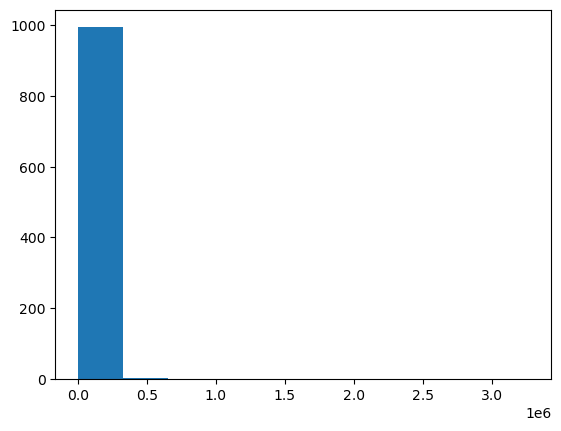

In [7]:
ln = scvi_model.get_latent_library_size()
plt.hist(ln)

In [8]:
scvi_samples = scvi_model.posterior_predictive_sample()

0.7971199279982 0.69
Performing UMAP on combined dataset (2000 samples, 2000 features) across 2 datasets...


/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/umap/umap_.py:1952: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


UMAP completed. Generating visualizations...


([array([[ 9.118957  , -2.857136  ],
         [ 8.315708  , -4.103768  ],
         [ 9.140362  , -0.8417984 ],
         ...,
         [11.782092  , -0.88144606],
         [17.202383  ,  5.366625  ],
         [12.851426  ,  0.66544926]], shape=(1000, 2), dtype=float32),
  array([[ 7.9664617, -4.5392485],
         [ 7.8596697, -3.667926 ],
         [ 9.122136 , -0.8139737],
         ...,
         [12.513294 , -1.5357502],
         [16.029905 ,  2.6388144],
         [16.752867 ,  3.8922572]], shape=(1000, 2), dtype=float32)],
 <Figure size 1400x600 with 2 Axes>)

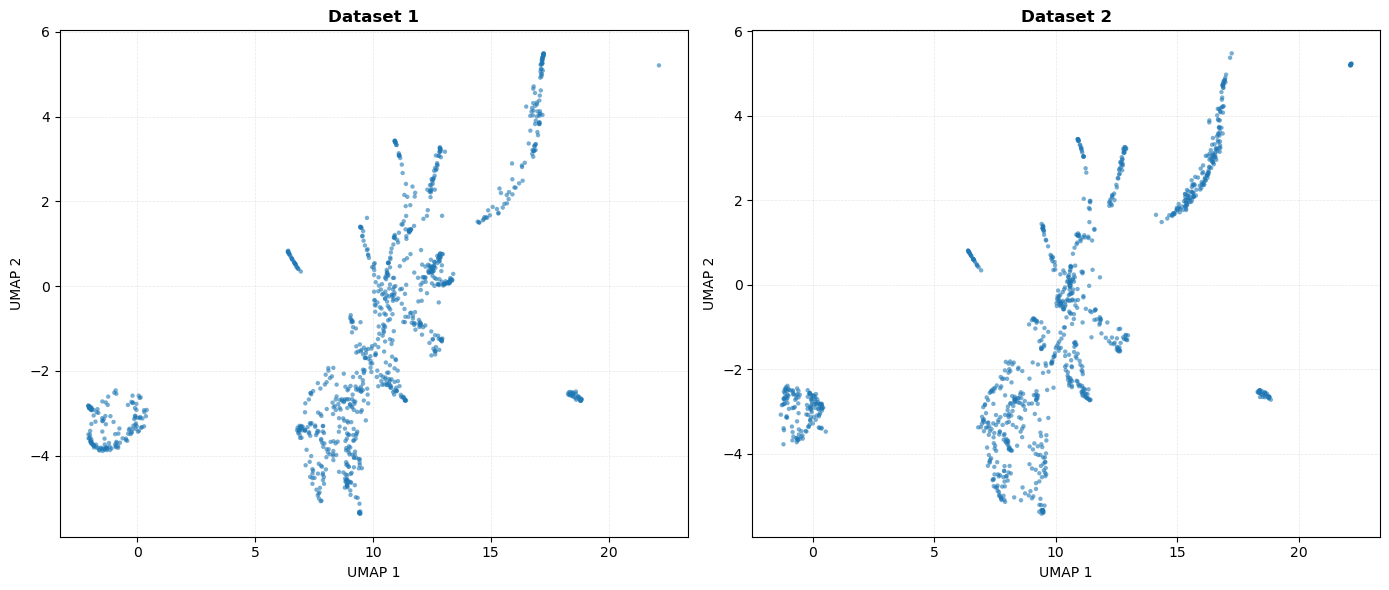

In [10]:
dense_samples = scvi_samples.todense()
auc, acc = knn_discriminability(dense_samples, muris_1k.X)
print(auc, acc)
compare_umap([dense_samples, muris_1k.X])

Standard VAE sampling:
1. Draw $z \sim \mathcal{N}(0, I)$
2. $x = f_{\text{decoder}}(z)$

In [12]:
scvi_model.summary_stats

n_batch: 1
n_cells: 1000
n_extra_categorical_covs: 1
n_extra_continuous_covs: 0
n_labels: 1
n_vars: 2000

In [14]:
muris_1k.obs

,celltype,n_genes,counts,_scvi_batch,_scvi_labels
503989,Trachea,1250,3733.0,0,0
CCAATCCAGCGCCTTG-1,Bladder,2874,9796.0,0,0
ACACTGAGTACAGTGG-1,Mammary_Gland,3194,15923.0,0,0
ACTGATGTCGGGAGTA-1,Spleen,833,2125.0,0,0
CAAGATCGTGAGGGAG-1,Spleen,1015,2334.0,0,0
...,...,...,...,...,...
CCGGGATAGATCCCAT-1,Marrow,630,7957.0,0,0
CTTAGGAGTCCCTACT-1,Tongue,3443,16256.0,0,0
AGAATAGCATATGGTC-1,Kidney,1071,2372.0,0,0
GACGTTACAGAGCCAA-1,Spleen,1385,3932.0,0,0


In [ ]:
scvi_model.get_latent

In [16]:
def sample_from_prior(model, n_samples, data):
    device = model.device
    n_latent = model.get_latent_representation().shape[1]
    z = torch.randn(n_samples, n_latent).to(device)

    obs_indices = np.random.choice(len(data), n_samples, replace=True)
    batch_indices = torch.tensor(
        data.obs['_scvi_batch'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    labels = torch.tensor(
        data.obs['_scvi_labels'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    latent_library = model.get_latent_library_size(indices = obs_indices, give_mean=False)
    library = torch.tensor(np.log(latent_library), dtype=torch.float32).to(device)

    model.module.eval()
    with torch.no_grad():
        scvi_prior_samples = model.module.generative(z = z, 
                                                        batch_index = batch_indices, 
                                                        library = library,
                                                        y = labels)
    px = scvi_prior_samples['px']
    simulated_data = px.sample().cpu().numpy()
    return simulated_data

simulated_data = sample_from_prior(scvi_model, 1000, muris_1k)

In [17]:
knn_discriminability(simulated_data, muris_10k.X)

(0.9367617415352854, 0.96)

In [ ]:
scvi_latent_samples = scvi_model.get_latent_representation()
scvi_latent_samples.shape


(1000, 10)

In [30]:
import anndata as ad
encoded_muris1k = ad.AnnData(X=scvi_latent_samples, obs=muris_1k.obs)
encoded_muris1k

AnnData object with n_obs × n_vars = 1000 × 10
    obs: 'celltype', 'n_genes', 'counts', '_scvi_batch', '_scvi_labels'

In [31]:
from scdeepsim.lightning_diffusion import LightningDiffusion
import pytorch_lightning as pl
from scdeepsim.dataset import ScDataModule
import os

latent_dm = ScDataModule(
    encoded_muris1k,
    label_key="celltype",
    encoder="LabelEncoder",
    batch_size=128,
    val_split=0.1,
    balanced_sampling = False,
)

latent_dm.setup()

dim = encoded_muris1k.X.shape[1]
num_classes = int(latent_dm.train_dataset.dataset.classes.max()) + 1

diffusion = LightningDiffusion(
    input_dim=dim,
    num_classes=num_classes,
    use_ema=True,
    ema_decay=0.999)

trainer = pl.Trainer(
    max_epochs=400,
    accelerator="auto",
    devices="auto",
    log_every_n_steps=50,
    enable_checkpointing=True,
    logger=True,
    default_root_dir="lightning_logs/muris1k/diffusion",
)

diffusion_model_path = "checkpoints/muris1k/trained_diffusion_model.ckpt"
if os.path.exists(diffusion_model_path):
    diffusion = LightningDiffusion.load_from_checkpoint(diffusion_model_path)
else:
    trainer.fit(diffusion, latent_dm)
    trainer.save_checkpoint(diffusion_model_path)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | model     | DenoisingUNet     | 7.0 M  | train
1 | diffusion | GaussianDiffusion | 7.0 M  | train
2 | ema_model | DenoisingUNet     | 7.0 M  | eval 
--------------------------------------------------------
7.0 M     Trainable params
7.0 M     Non-trainable params
14.0 M    Total params
55.927    Total estimated model params size (MB)
92        Modules in train mode
91        Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (8) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/miniconda3/envs/lightning/lib/python3.12/site-packages/pytorch_

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


In [32]:
diffusion.eval()

with torch.no_grad():
    diffusion_latent_samples = diffusion.sample(num_samples=1000,
                                    sampling_timesteps=1000,
                                    ddim_sampling_eta=0.1,
                                    use_ema=True,
                                    clip_denoised=False, 
                                    )


sampling loop time step:   0%|          | 0/1000 [00:00<?, ?it/s]

In [33]:
knn_discriminability(diffusion_latent_samples, scvi_latent_samples)

(0.8542588564714118, 0.76)

In [34]:
def sample_from_z(model, n_samples, data, z):
    device = model.device
    obs_indices = np.random.choice(len(data), n_samples, replace=True)
    batch_indices = torch.tensor(
        data.obs['_scvi_batch'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    labels = torch.tensor(
        data.obs['_scvi_labels'].values[obs_indices], dtype=torch.long
    ).unsqueeze(1).to(device)

    latent_library = model.get_latent_library_size(indices = obs_indices, give_mean=False)
    library = torch.tensor(np.log(latent_library), dtype=torch.float32).to(device)

    model.module.eval()
    with torch.no_grad():
        scvi_prior_samples = model.module.generative(z = z, 
                                                        batch_index = batch_indices, 
                                                        library = library,
                                                        y = labels)
    px = scvi_prior_samples['px']
    simulated_data = px.sample().cpu().numpy()
    return simulated_data

simulated_data = sample_from_z(scvi_model, 1000, muris_1k, diffusion_latent_samples)
knn_discriminability(simulated_data, muris_1k.X)

(0.9118102952573814, 0.8275)

In [37]:
simulated_data = sample_from_z(scvi_model, 1000, muris_1k, torch.tensor(scvi_latent_samples))
knn_discriminability(simulated_data, muris_1k.X)

(0.9405860146503663, 0.8625)